In [3]:
import pandas as pd

df= pd.read_csv(r"C:\Users\USER\Downloads\Telegram Desktop\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
inputs = df.drop(['PassengerId','Survived','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')

In [5]:
inputs.head()

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [6]:
target = df['Survived']

In [7]:
target.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()

In [14]:
inputs['sex_n']= le_sex.fit_transform(inputs['Sex'])

In [15]:
inputs.head()

,Pclass,Sex,Age,Fare,sex_n
0,3,male,22.0,7.2500,1
1,1,female,38.0,71.2833,0
2,3,female,26.0,7.9250,0
3,1,female,35.0,53.1000,0
4,3,male,35.0,8.0500,1


In [18]:
inputs_n = inputs.drop(['Sex'],axis='columns')

In [19]:
inputs_n.head()

,Pclass,Age,Fare,sex_n
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1


In [21]:
inputs_n

,Pclass,Age,Fare,sex_n
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1
...,...,...,...,...
886,2,27.0,13.0000,1
887,1,19.0,30.0000,0
888,3,NaN,23.4500,0
889,1,26.0,30.0000,1


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(inputs_n,target,test_size=0.2)

In [23]:
len(x_train)

712

In [24]:
len(x_test)

179

In [51]:
from sklearn import tree
model = tree.DecisionTreeClassifier()


In [52]:
model.fit(inputs_n,target)

DecisionTreeClassifier()

In [54]:
model.score(inputs_n,target)

0.9797979797979798

In [55]:
y_pred = model.predict(x_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[108,   0],
       [  1,  70]], dtype=int64)

Text(33.22222222222222, 0.5, 'Truth')

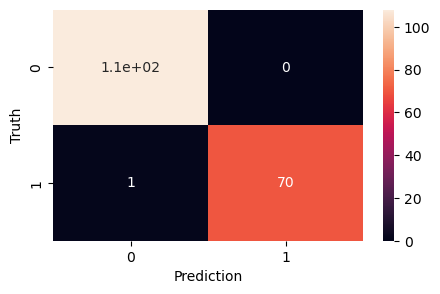

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=[5,3])
sns.heatmap(cm,annot=True)
plt.xlabel('Prediction')
plt.ylabel('Truth')

Text(33.22222222222222, 0.5, 'Truth')

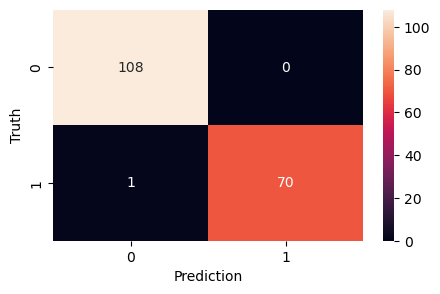

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=[5,3])
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')